In [1]:
# importaciones
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.gridspec import GridSpec

In [2]:
# cargar el csv
df = pd.read_csv('/content/One_Piece_Episode_wise_Summary_1-1130.csv')
print(f"Dataset cargada: {df.shape[0]:,} filas y {df.shape[1]} columnas")

Dataset cargada: 1,130 filas y 5 columnas


In [3]:
# primeras 5 filas
df.head()

,episode,episode_name,arc,summary,character_appearances
0,1,I'm Luffy! The Man Who Will Become the Pirate ...,Romance Dawn Arc,Luffy is cast at sea in a barrel. Sailors on a...,"['Nami', 'Alvida', 'Koby', 'Heppoko', 'Peppoko..."
1,2,The Great Swordsman Appears! Pirate Hunter Ror...,Romance Dawn Arc,"Luffy and Koby arrive at Shells Town, a town w...","['Monkey D. Luffy', 'Koby', 'Roronoa Zoro', 'R..."
2,3,Morgan vs. Luffy! Who's This Mysterious Beauti...,Romance Dawn Arc,"Luffy returns the katana to Zoro, who uses the...","['Roronoa Zoro', 'Monkey D. Luffy', 'Morgan', ..."
3,4,Luffy's Past! The Red-Haired Shanks Appears,Orange Town Arc,The burglar girl's dinghy is discovered by thr...,"['Tightrope Walking Funan Bros', 'Nami', 'Monk..."
4,5,"Fear, Mysterious Power! Pirate Clown Captain B...",Orange Town Arc,"The girl introduces herself as Nami, a thief t...","['Nami', 'Superhuman Domingos', 'Pinky', 'Monk..."


In [4]:
# ultimas filas
display(df.tail(3))

,episode,episode_name,arc,summary,character_appearances
1127,1128,The Nightmare Strikes - Warrior God of Science...,Egghead Arc,"As the Pacifistas begin attacking the Marines,...","['Jaygarcia Saturn', 'Shaka', 'Lilith', 'Pytha..."
1128,1129,Kuma's Past - Better Off Dead in This World,Egghead Arc,Doberman orders all lower-ranking Marines to l...,"['Jaygarcia Saturn', 'Jewelry Bonney', 'Doberm..."
1129,1130,A History Erased! God Valley Of Despair,Egghead Arc,The hunting competition in God Valley began an...,"['Bartholomew Kuma', 'Clapp', 'Emporio Ivankov..."


In [5]:
# filas aleatorias
display(df.sample(3, random_state=42))

,episode,episode_name,arc,summary,character_appearances
703,704,The Time is Ticking Down! Seize the Ope Ope no...,Dressrosa Arc,Under attack from Donquixote Doflamingo's stri...,"['Bellamy', 'Monkey D. Luffy', 'Donquixote Dof..."
900,901,Charging into the Enemy's Territory - Bakura T...,Wano Country Arc,Gazelleman barks with laughter as he speeds in...,"['Monkey D. Luffy', 'Gazelleman', 'Tsuru', 'O-..."
773,774,A Battle to Defend Zou - Luffy and Zunesha!,Zou Arc,Zou continues to shake from the cannon fire of...,"['Kouzuki Momonosuke', 'Monkey D. Luffy', 'Uso..."


In [6]:
# forma y nombres de columnas
print(f"Forma:    {df.shape}        → {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"Tamaño:   {df.size:,} celdas en total")
print(f"Columnas: {df.columns.tolist()}")

Forma:    (1130, 5)        → 1130 filas × 5 columnas
Tamaño:   5,650 celdas en total
Columnas: ['episode', 'episode_name', 'arc', 'summary', 'character_appearances']


In [7]:
# info: tipos, nulos y memoria
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1130 entries, 0 to 1129
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   episode                1130 non-null   int64 
 1   episode_name           1130 non-null   object
 2   arc                    1130 non-null   object
 3   summary                1130 non-null   object
 4   character_appearances  1130 non-null   object
dtypes: int64(1), object(4)
memory usage: 44.3+ KB


In [8]:
# estadisticas de columnas
df.describe().round(2)

,episode
count,1130.00
mean,565.50
std,326.35
min,1.00
25%,283.25
50%,565.50
75%,847.75
max,1130.00


In [9]:
# columnas de texto
df.describe(include='object')

,episode_name,arc,summary,character_appearances
count,1130,1130,1130,1130
unique,1130,65,1130,1130
top,A History Erased! God Valley Of Despair,Wano Country Arc,The hunting competition in God Valley began an...,"['Bartholomew Kuma', 'Clapp', 'Emporio Ivankov..."
freq,1,190,1,1


In [10]:
# renombrar columnas sin modificar el dataframe original
df = df.rename(columns={
    'episode':                'episodio',
    'episode_name':           'nombre_episodio',
    'arc':                    'arco',
    'summary':                'resumen',
    'character_appearances':  'aparicion_personajes',
})

print("Columnas renombradas:")
print(df.columns.tolist())

Columnas renombradas:
['episodio', 'nombre_episodio', 'arco', 'resumen', 'aparicion_personajes']


In [11]:
# nulos y duplicados por columna
nulos = df.isna().sum() # .isna() devuelve True/False, .sum() los cuenta
print("Valores nulos por columna:\n")
print(nulos)

# duplicados
print(f"\n→ Total de nulos: {nulos.sum()}")
print(f"→ Filas duplicadas: {df.duplicated().sum()}")
print(f"→ Episodios duplicados: {df.duplicated(subset='episodio').sum()}")

Valores nulos por columna:

episodio                0
nombre_episodio         0
arco                    0
resumen                 0
aparicion_personajes    0
dtype: int64

→ Total de nulos: 0
→ Filas duplicadas: 0
→ Episodios duplicados: 0


In [12]:
# episodios por arco
episodios_jaya = df[df['arco'] == 'Jaya Arc']
print("Episodios del arco de Jaya:")
episodios_jaya.head()

Episodios del arco de Jaya:


,episodio,nombre_episodio,arco,resumen,aparicion_personajes
143,144,"The Log is Taken! Salvage King, Masira!",Jaya Arc,The Straw Hat Pirates notice some debris falli...,"['Monkey D. Luffy', 'Nami', 'Usopp', 'Tony Ton..."
144,145,Monsters Appear! Don't Touch the Whitebeard Pi...,Jaya Arc,A turtle-like Sea King surfaces near Nami and ...,"['Nami', 'Usopp', 'Tony Tony Chopper', 'Nico R..."
145,146,"Stop Dreaming! The City of Ridicule, Mock Town!",Jaya Arc,"In a bar, Roshio and Bellamy are gambling and ...","['Bellamy', 'Roshio', 'Sarquiss', 'Usopp', 'Ro..."
146,147,The Pirate's Summit! The Man Who Talks of Drea...,Jaya Arc,It opens in the bar where Bellamy is still hit...,"['Nami', 'Roronoa Zoro', 'Monkey D. Luffy', 'S..."
147,148,The Legendary Family! 'Liar Noland',Jaya Arc,Usopp tries repairing the damages from the son...,"['Usopp', 'Tony Tony Chopper', 'Roronoa Zoro',..."


In [13]:
import ast

# saber cuantos personajes aparecen por episodio
df['num_personajes'] = df['aparicion_personajes'].apply(lambda x: len(ast.literal_eval(x)))

In [14]:
# episodios con mas de 14 personajes
muchos_personajes = df[df['num_personajes'] > 14]

In [15]:
# buscar todos los episodios donde aparece 'Buggy'
filtro_buggy = df[df['aparicion_personajes'].apply(lambda lista: 'Buggy' in lista)]
filtro_buggy.head()

,episodio,nombre_episodio,arco,resumen,aparicion_personajes,num_personajes
2,3,Morgan vs. Luffy! Who's This Mysterious Beauti...,Romance Dawn Arc,"Luffy returns the katana to Zoro, who uses the...","['Roronoa Zoro', 'Monkey D. Luffy', 'Morgan', ...",12
3,4,Luffy's Past! The Red-Haired Shanks Appears,Orange Town Arc,The burglar girl's dinghy is discovered by thr...,"['Tightrope Walking Funan Bros', 'Nami', 'Monk...",18
4,5,"Fear, Mysterious Power! Pirate Clown Captain B...",Orange Town Arc,"The girl introduces herself as Nami, a thief t...","['Nami', 'Superhuman Domingos', 'Pinky', 'Monk...",8
5,6,Desperate Situation! Beast Tamer Mohji vs. Luffy!,Orange Town Arc,"Having warded off the Buggy Pirates, a wounded...","['Buggy', 'Nami', 'Monkey D. Luffy', 'Roronoa ...",9
6,7,Grand Duel! Zoro the Swordsman vs. Cabaji the ...,Orange Town Arc,Luffy knocks Boodle unconscious to prevent him...,"['Richie', 'Monkey D. Luffy', 'Chouchou', 'Moh...",14


In [16]:
# saber si aparece luffy y zoro
df['aparece_luffy'] = df['aparicion_personajes'].apply(lambda x: 'Luffy' in x)
df['aparece_zoro'] = df['aparicion_personajes'].apply(lambda x: 'Zoro' in x)

In [17]:
# arco especifico y que NO este luffy
condicion = (df['arco'] == 'Dressrosa Arc') & (~df['aparece_luffy'])
episodios_especificos = df[condicion]
episodios_especificos.head()

,episodio,nombre_episodio,arco,resumen,aparicion_personajes,num_personajes,aparece_luffy,aparece_zoro
700,701,Sad Memories - Law the Boy from the White City!,Dressrosa Arc,"In the town of Spider Miles in the North Blue,...","['Trafalgar D. Water Law', 'Donquixote Rosinan...",15,False,False
701,702,A Celestial Dragon! Doffy's Stormy Past,Dressrosa Arc,"In Spider Miles, as Donquixote Doflamingo slee...","['Donquixote Doflamingo', 'Donquixote Homing',...",18,False,False
704,705,The Moment of Resolution - Corazon's Farewell ...,Dressrosa Arc,Vice Admiral Tsuru walks down the gangplank of...,"['Tsuru', 'Hototogisu', 'Donquixote Rosinante'...",18,False,False
705,706,"Advance, Law - The Kindhearted Man's Final Fight!",Dressrosa Arc,Inside the Birdcage surrounding the ghost town...,"['X Drake', 'Donquixote Doflamingo', 'Diez Bar...",17,False,False
711,712,Storm and Stress - Hakuba vs. Dellinger,Dressrosa Arc,As Punc Rock Fest blows away Gladius' subordin...,"['Gladius', 'Bartolomeo', 'Cavendish', 'Nico R...",11,False,False


In [18]:
# seleccionamos solo el nombre del episodio y el resumen
resumen_rapido = df[['nombre_episodio', 'resumen']]

In [19]:
# ordenar segun cantidad de personajes y arco
top_episodios = df[df['arco'] == 'Dressrosa Arc'].sort_values(by='num_personajes', ascending=False) # ascending=False pone los numeros mas grandes primero
top_episodios.head()

,episodio,nombre_episodio,arco,resumen,aparicion_personajes,num_personajes,aparece_luffy,aparece_zoro
745,746,The Numerous Rivals Struggle Amongst Themselve...,Dressrosa Arc,"On the Yonta Maria, the Straw Hat Grand Fleet'...","['Monkey D. Luffy', 'Ideo', 'Franky', 'Sai', '...",73,True,True
735,736,Sending a Shock Wave - The Worst Generation Go...,Dressrosa Arc,The people on Dressrosa and the neighboring is...,"['Riku Doldo III', 'Issho', 'Elizabello II', '...",60,True,True
733,734,To Be Free! Dressrosa's Delight!,Dressrosa Arc,The citizens of Dressrosa run away from the pa...,"['Donquixote Doflamingo', 'Monkey D. Luffy', '...",57,True,True
744,745,Sons' Cups - Straw Hat Fleet is Formed!,Dressrosa Arc,"Somewhere at sea, a group of pirates form an a...","['Orlumbus', 'Bartolomeo', 'Hajrudin', 'Ideo',...",51,True,True
676,677,The Legend is Back! Kyros' All-out Blow,Dressrosa Arc,Usopp and Sugar scream as the latter passes ou...,"['Sugar', 'Usopp', 'Trebol', 'Nico Robin', 'Bo...",50,True,True


In [20]:
# clasificar episodio por numero de personajes
def clasificar_relleno(cantidad):
  if cantidad <= 8:
    return 'Enfoque Individual'
  elif cantidad >= 9:
    return 'Batalla Masiva'

df['tipo_episodio'] = df['num_personajes'].apply(clasificar_relleno)

In [21]:
# promedio de personajes segun arco
resumen_arcos = df.groupby('arco')['num_personajes'].mean().sort_values(ascending=False)

print("Promedio de personajes por arco:")
print(resumen_arcos)

Promedio de personajes por arco:
arco
Time to Depart – Wano Country and the Straw Hats         63.000000
One Piece x Toriko x Dragon Ball Crossover               55.000000
Reverie/ Levely Arc                                      54.333333
Marineford Arc                                           39.290323
Wano Country Arc                                         36.315789
                                                           ...    
Post-Arabasta Arc                                        10.200000
Goat Island Arc                                          10.000000
Warship Island Arc                                        9.625000
Luffy’s Past                                              6.000000
One Piece Anime 20th Anniversary Special Romance Dawn     5.000000
Name: num_personajes, Length: 65, dtype: float64


In [22]:
# 'mean' = promedio, 'count' = total de episodios, 'max' = el episodio con mas personajes
analisis_arcos = df.groupby('arco')['num_personajes'].agg(['mean', 'median', 'min', 'max'])
print("Análisis de arcos:")
print(analisis_arcos)

Análisis de arcos:
                                                    mean  median  min  max
arco                                                                      
A Special Retrospective Before Marineford Arc  32.000000    32.0   31   33
Amazon Lily Arc                                25.000000    23.0   12   42
Arabasta Arc                                   19.027778    20.0   11   35
Arlong Park Arc                                15.214286    15.5   12   23
Baratie Arc                                    10.250000    10.0    7   15
...                                                  ...     ...  ...  ...
Water 7 Arc                                    21.000000    21.0    9   31
Whisky Peak Arc                                13.750000    14.5   10   16
Whole Cake Island Arc                          27.600000    25.0    7   66
Zou Arc                                        30.035714    29.5   15   66
Z’s Ambition Arc                               15.750000    16.0   15   16

[65 r

In [23]:
import seaborn as sns

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64],
 [Text(0, 0, 'Romance Dawn Arc'),
  Text(1, 0, 'Orange Town Arc'),
  Text(2, 0, 'Syrup Village Arc'),
  Text(3, 0, 'Baratie Arc'),
  Text(4, 0, 'Arlong Park Arc'),
  Text(5, 0, 'Loguetown Arc'),
  Text(6, 0, 'Buggy’s Crew Adventure Chronicles'),
  Text(7, 0, 'Warship Island Arc'),
  Text(8, 0, 'Reverse Mountain Arc'),
  Text(9, 0, 'Whisky Peak Arc'),
  Text(10, 0, 'Diary of Koby and Helmeppo Arc'),
  Text(11, 0, 'Little Garden Arc'),
  Text(12, 0, 'Drum Island Arc'),
  Text(13, 0, 'Arabasta Arc'),
  Text(14, 0, 'Inside Arabasta Arc'),
  Text(15, 0, 'Post-Arabasta Arc'),
  Text(16, 0, 'Goat Island Arc'),
  Text(1

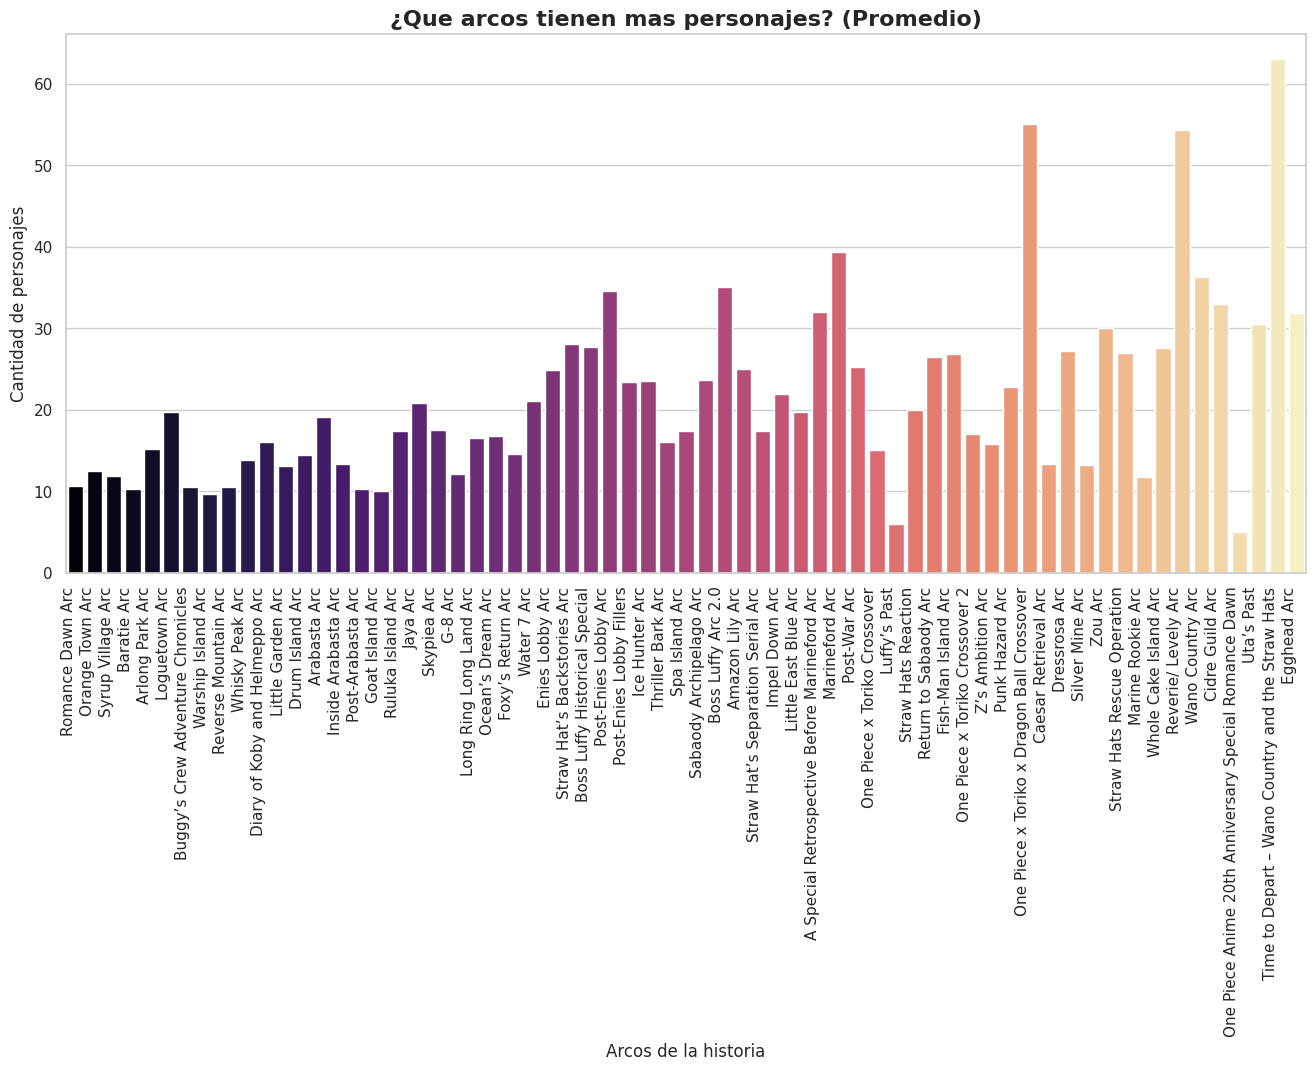

In [24]:
# tamaño y estilo de la grafica
plt.figure(figsize=(16, 7))
sns.set_theme(style="whitegrid")

# creamos la grafica de barras
ax = sns.barplot(x='arco', y='num_personajes', data=df, errorbar=None, palette='magma', hue='arco', legend=False)

# estilo de titulos y etiquetas
plt.title('¿Que arcos tienen mas personajes? (Promedio)', fontsize=16, fontweight='bold')
plt.xlabel('Arcos de la historia', fontsize=12)
plt.ylabel('Cantidad de personajes', fontsize=12)

# rotar nombres de los arcos
plt.xticks(rotation=90, ha='right')

In [25]:
nombre_csv = 'resultado_arcos_one_piece.csv'
df.to_csv(nombre_csv, index=False)

resumen_arcos.to_csv('resumen_arcos.csv')

print(f"El archivo '{nombre_csv}' se ha creado con éxito.")

try:
    from google.colab import files
    files.download(nombre_csv)
    files.download('resultado_arcos_one_piece.csv')
except ImportError:
    print("No se encontraron archivos para descargar.")

El archivo 'resultado_arcos_one_piece.csv' se ha creado con éxito.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>